<a href="https://colab.research.google.com/github/Valeriy1990/Else/blob/main/VSEGPT_%D0%90%D0%BB%D1%8C%D1%82%D0%B5%D1%80%D0%BD%D0%B0%D1%82%D0%B8%D0%B2%D0%B0_OpenAI_%D0%B8_OpenRouter_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

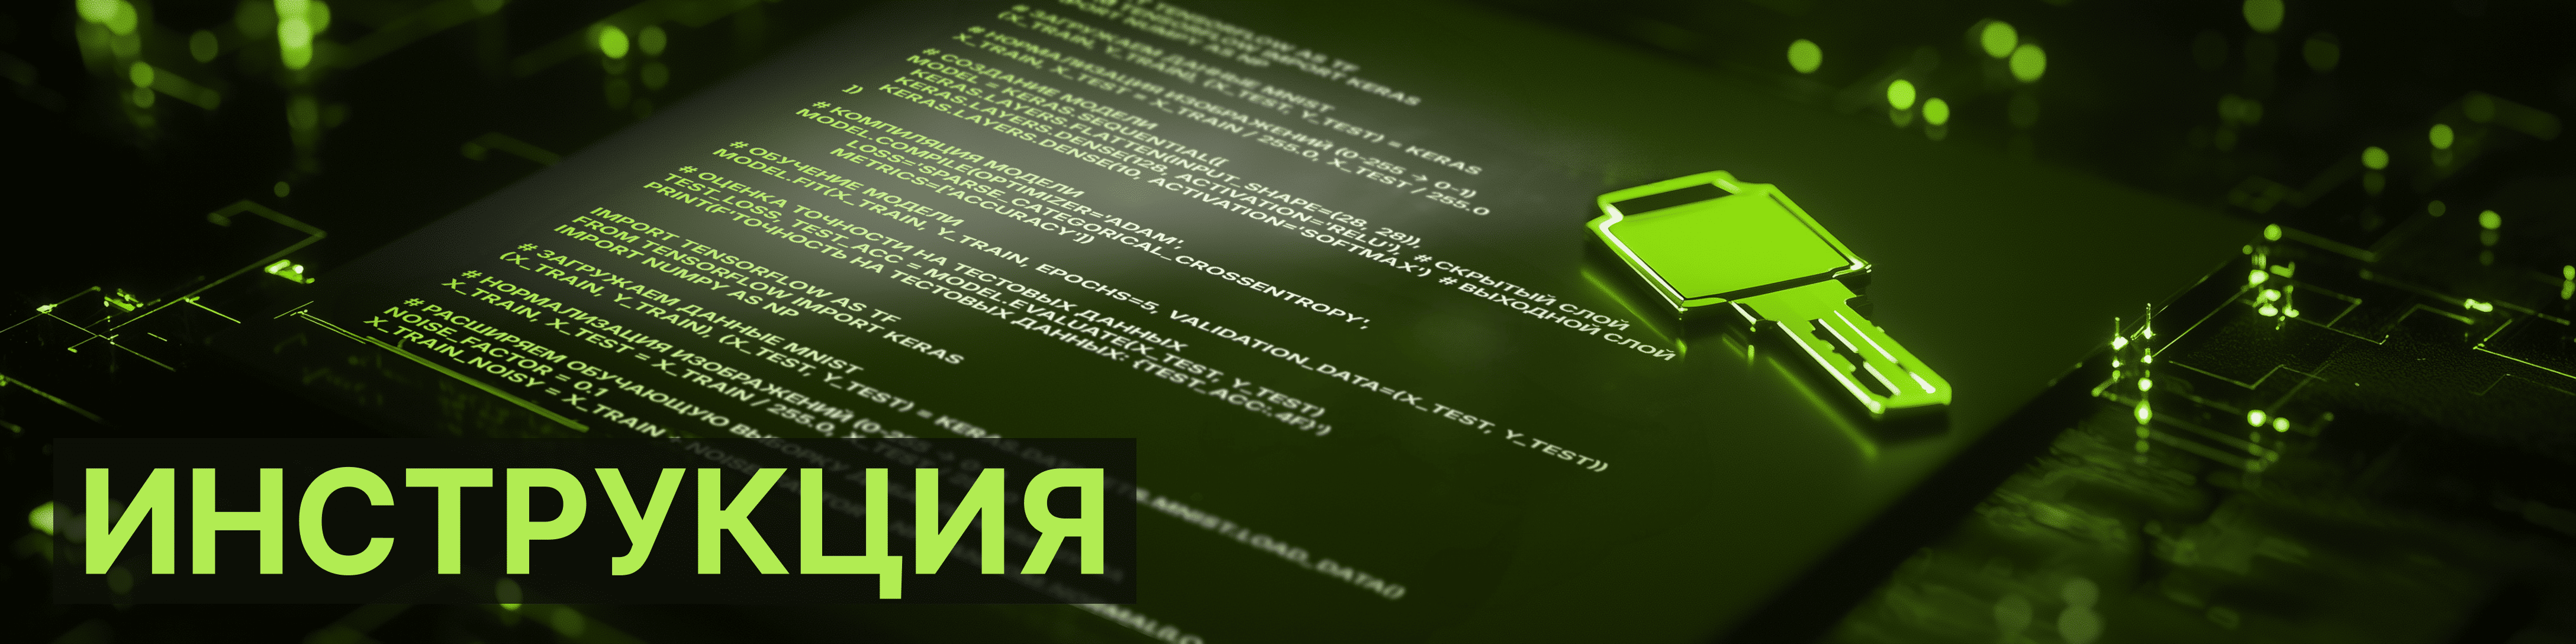

## Альтернативный вариант подключения к OpenAI API через сервис VseGPT

Зайдите на сайт https://vsegpt.ru.

* Ознакомьтесь с ценами и условиями использования.

* Зарегистрируйте учетную запись (https://vsegpt.ru/Reg).

* Подтвердите адрес электронной почты, пройдя по ссылке из письма (придет на ящик, указанный при регистрации).

* Пополните баланс вашей учетной записи всего от 250 рублей (принимают Российские банковские карты).

* Деньги поступают в течение 5-ти минут.

* Получите ключ API на сайте VseGpt для доступа к API OpenAI

* Добавьте полученный ключ в переменную окружения Google Colab.

* Помимо ключа необходимо иметь подписку, например, базовую 199 руб/мес. Подключить подписку можно на странице "Баланс и подписка" (https://vsegpt.ru/User/Money).


### Добавление ключа в переменную окружения Google Colab

Процесс добавления API ключа в Google Colab.

**Пошаговая инструкция:**

1. Нажать на значок ключа (находится в левой части интерфейса)

2. Нажать на кнопку "Добавить секрет"

3. В поле названия ввести название ключа без кавычек
   (это название будет использоваться в коде для обращения к ключу)

4. Вставить сам полученный API ключ в соответствующее поле (см. рис. 1).

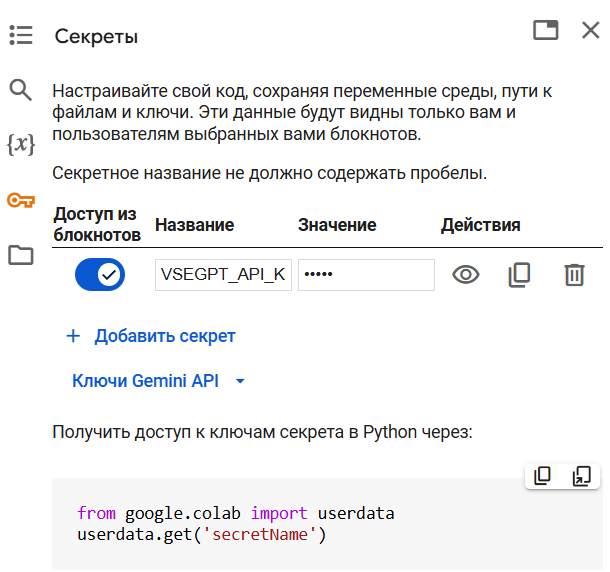

**Рис. 1. Хранение секретов в Google Colab**





После добавления ключа его можно использовать в коде как переменную окружения с заданным названием. Это безопасный способ хранения секретных данных, так как сам ключ не будет виден в коде.

Преимущества такого подхода:
- Безопасное хранение секретных данных
- Ключ не отображается в коде
- Удобное управление через интерфейс
- Возможность легко обновлять значение ключа при необходимости

### Импорт библиотеки для работы с OpenAI

Загружаем библиотеку OpenAI и Httpx для решения проблем в openAI с зависимостями, приводящим к ошибке:

`TypeError: Client.__init__() got an unexpected keyword argument 'proxies'`

In [ ]:
# Загружаем библиотеку OpenAI
!pip install openai==1.55.3 httpx==0.27.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.6/389.6 kB 7.2 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.54.4
    Uninstalling openai-1.54.4:
      Successfully uninstalled openai-1.54.4


### Классическое подключение с ключем от OpenAI

Код содержит два альтернативных способа установки API ключа для OpenAI:

1. Первый способ - для обычного использования без Google Colab:

```python
import getpass
import openai
import os

# Запрашивает ключ API у пользователя через безопасный ввод
openai_key = getpass.getpass("OpenAI API Key:")

# Устанавливает ключ как переменную окружения
os.environ["OPENAI_API_KEY"] = openai_key

# Также устанавливает ключ напрямую для библиотеки openai
openai.api_key = openai_key
```

2. Второй способ - для использования в Google Colab:

```python
import openai
import os
from google.colab import userdata

# Получает ключ API из секретов Colab
key = userdata.get('OPENAI_API_KEY')

# Устанавливает полученный ключ как переменную окружения
os.environ["OPENAI_API_KEY"] = key
```

Основные отличия:
- Первый вариант использует getpass для безопасного ввода ключа пользователем
- Второй вариант получает ключ из секретов Google Colab
- В обоих случаях ключ устанавливается как переменная окружения
- В первом варианте дополнительно устанавливается ключ напрямую для библиотеки openai

Выбор способа зависит от среды выполнения - обычный Python или Google Colab.



### Подключение с ключом VseGPT

In [ ]:
# Запустите эту ячейку, если используете сервер VseGpt для подключения к API OpenAI
import os
from google.colab import userdata

# Использование ключа API от VseGpt
key = userdata.get('VSEGPT_API_KEY')
os.environ["OPENAI_API_KEY"] = key

# Адрес сервера VseGpt
base_url = "https://api.vsegpt.ru/v1"
os.environ["OPENAI_BASE_URL"] = base_url

Далее необходимо выбрать [модель](https://vsegpt.ru/Docs/Models).

Например, `openai/gpt-3.5-turbo`. При выборе `anthropic/claude-3-haiku` `base_url` менять не надо, так как используется унифицированное API. Больше примеров смотрите [здесь](https://vsegpt.ru/Docs/API).

**Получения ответа от ChatGPT.**

In [ ]:
# Обращаемся к gpt, и получаем ответ:
from openai import OpenAI

client = OpenAI() # создается экземпляр класса OpenAI
stream = client.chat.completions.create(
    model="openai/gpt-3.5-turbo",     # выбираем модель
    messages=[{"role": "system", "content": "Ты - японский поэт. На все вопросы отвечаешь Хокку!"},
              {"role": "user", "content": "В каком году родился Сальвадор Дали?"}
              ],
)
answer = stream.choices[0].message.content # получаем ответ от модели, только текст.
print(answer)                              # выводим ответ

Сальвадор Дали,  
В девятнадцатом веке,  
В тысяча девять.


Все отлично, ответ получен!